# Clinical Supply Chain (CSC) — RL Pipeline Walkthrough

This notebook walks through the **RL-based supply chain planning pipeline** end-to-end:
from loading synthetic clinical trial data, through the 4 trained PPO agents, to inspecting
every output — with deep dives into observations, actions, and rewards.

The RL pipeline is a **drop-in replacement** for the LLM-based pipeline. Both produce
identical Pydantic model outputs and write to the same `SharedState` blackboard.

---

## System Architecture

```
┌─────────────────────────────────────────────────────────────────────┐
│                    RL SUPPLY CHAIN PIPELINE                          │
│                                                                       │
│  JSON Data Files                                                      │
│  (trials, sites,  ──► SharedState Blackboard                         │
│   plants, depots,      (in-memory, read/write by all agents)         │
│   materials, ...)      │                                              │
│                        │                                              │
│                        ▼                                              │
│              ┌─────────────────┐                                      │
│              │  RL Agent 1     │  Demand Forecast                     │
│              │  DemandPlan ◄───┤  obs → PPO → action → DemandPlan      │
│              └────────┬────────┘  150×10 obs, 150×2 actions           │
│                       │                                               │
│                       ▼                                               │
│              ┌─────────────────┐                                      │
│              │  RL Agent 2     │  Capacity Allocation                │
│              │  CapacityPlans◄┤  obs → PPO → action → 3 plans        │
│              └────────┬────────┘  10×4+20×5 obs, 10×20 actions       │
│                       │                                               │
│                       ▼                                               │
│              ┌─────────────────┐                                      │
│              │  RL Agent 3     │  Batch Scheduling                   │
│              │  SupplyPlan  ◄─┤  obs → PPO → action → batches        │
│              └────────┬────────┘  40×5+80×3+2 obs, 40×3 actions    │
│                       │                                               │
│                       ▼                                               │
│              ┌─────────────────┐                                      │
│              │  RL Agent 4     │  Inventory & Safety Stock           │
│              │  SupplyPlan  ◄─┤  obs → PPO → action → orders         │
│              └─────────────────┘  100×8 obs, 100×2 actions            │
│                                                                       │
└─────────────────────────────────────────────────────────────────────┘
```

**Key difference from the LLM pipeline:** Each RL agent performs a single forward pass
through a trained neural network (PPO) instead of multi-turn LLM tool-calling.
The observation builder encodes SharedState into a flat numpy vector, the model predicts
an action, and the action mapper converts it back into a typed Pydantic output.

## 0. Setup

In [ ]:
# Install RL dependencies (skip if already installed)
# !pip install -e ".[rl]"

In [1]:
import os, sys
from pathlib import Path

# Ensure the repo root is on the path so `csc` is importable
REPO_ROOT = Path(os.getcwd()).parent if "notebooks" in os.getcwd() else Path(os.getcwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

DATA_DIR = REPO_ROOT / "src" / "csc" / "data" / "output"
MODEL_DIR = REPO_ROOT / "src" / "csc" / "rl" / "models"

print(f"Repo root:  {REPO_ROOT}")
print(f"Data dir:   {DATA_DIR}")
print(f"Model dir:  {MODEL_DIR}")

Repo root:  c:\Users\Ferhat\Documents\GitHub\csc-skill-test
Data dir:   c:\Users\Ferhat\Documents\GitHub\csc-skill-test\src\csc\data\output
Model dir:  c:\Users\Ferhat\Documents\GitHub\csc-skill-test\src\csc\rl\models


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from csc.config import Config
from csc.orchestrator.state import SharedState
from csc.orchestrator.rl_pipeline import RLSupplyChainPipeline, RL_AGENT_SEQUENCE

# RL internals
from csc.rl.base_agent import BaseRLAgent
from csc.rl.obs_builders import (
    build_demand_obs, build_inventory_obs, build_batch_obs, build_capacity_obs,
    IndexMap, MAX_TRIAL_SITE_PAIRS, MAX_INVENTORY_POSITIONS, MAX_EQUIPMENT_LINES,
    MAX_MATERIALS, MAX_LOCATIONS, MAX_TRIALS,
    TSP_FEATURES, INV_FEATURES, EQL_FEATURES, MAT_FEATURES, LOC_FEATURES, TRL_FEATURES,
)
from csc.rl.action_mappers import map_demand_action, map_inventory_action, map_batch_action, map_capacity_action
from csc.rl.rewards import (
    demand_forecast_reward, inventory_reward,
    batch_scheduling_reward, capacity_allocation_reward,
)

# Agents
from csc.rl.agents.demand_agent import DemandRLAgent
from csc.rl.agents.capacity_agent import CapacityRLAgent
from csc.rl.agents.batch_agent import BatchRLAgent
from csc.rl.agents.inventory_agent import InventoryRLAgent

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

---

## 1. Load Reference Data

Load synthetic clinical supply chain data into `SharedState` — the same blackboard used by both the LLM and RL pipelines.

In [3]:
state = SharedState()
state.load_from_dir(DATA_DIR)

print("=== Reference Data Summary ===")
print(f"  Trials:               {len(state.trials)}")
print(f"  Clinical sites:       {len(state.sites)}")
print(f"  Plants:               {len(state.plants)}")
print(f"  Depots:               {len(state.depots)}")
print(f"  Equipment lines:      {len(state.equipment_lines)}")
print(f"  Changeover rules:     {len(state.changeover_rules)}")
print(f"  Enrollment forecasts: {len(state.enrollment_forecasts)}")
print(f"  Inventory positions:  {len(state.inventory_positions)}")
print(f"  Drug substances:      {len(state.materials.drug_substances)}")
print(f"  Drug products:        {len(state.materials.drug_products)}")
print(f"  Primary packs:        {len(state.materials.primary_packs)}")
print(f"  Finished goods:       {len(state.materials.finished_goods)}")

=== Reference Data Summary ===
  Trials:               15
  Clinical sites:       30
  Plants:               2
  Depots:               6
  Equipment lines:      31
  Changeover rules:     35
  Enrollment forecasts: 2627
  Inventory positions:  60
  Drug substances:      15
  Drug products:        15
  Primary packs:        15
  Finished goods:       15


---

## 2. Run the Full RL Pipeline

`RLSupplyChainPipeline` mirrors the LLM pipeline but uses trained PPO models. The 4 agents
run sequentially, each reading upstream outputs from SharedState:

1. **Demand Forecast** — predicts enrollment and kit demand per trial-site pair
2. **Capacity Allocation** — allocates plant/depot capacity across trials (also produces portfolio plan)
3. **Batch Scheduling** — schedules production batches on equipment lines
4. **Inventory & Safety Stock** — sets reorder quantities and safety stock targets

In [4]:
config = Config(method="rl", rl_model_dir=MODEL_DIR)
pipeline = RLSupplyChainPipeline(config)
pipeline.load_data(DATA_DIR)
final_state = pipeline.run_full()

Loaded data from c:\Users\Ferhat\Documents\GitHub\csc-skill-test\src\csc\data\output

Running RL Supply Chain Pipeline

Loaded RL model from c:\Users\Ferhat\Documents\GitHub\csc-skill-test\src\csc\rl\models\demand_forecast.zip

============================================================

  Demand Forecast (RL Agent)

...

Loaded RL model from c:\Users\Ferhat\Documents\GitHub\csc-skill-test\src\csc\rl\models\inventory_safety_stock.zip

============================================================

  Inventory Safety Stock (RL Agent)

============================================================

RL agent completed

In [5]:
# Verify all agent outputs are populated
output_keys = ["demand_plan", "portfolio_plan", "supply_plan", "depot_capacity_plan", "plant_capacity_plan"]
print("=== Pipeline Outputs ===")
for key in output_keys:
    val = final_state.get(key)
    status = type(val).__name__ if val is not None else "NOT SET"
    print(f"  {key:30s} -> {status}")

print(f"\n  Pipeline events logged: {len(final_state.events)}")
for ev in final_state.events:
    print(f"    [{ev.event_type:10s}] {ev.agent_name}: {ev.message}")

=== Pipeline Outputs ===
  demand_plan                    -> DemandPlan
  portfolio_plan                 -> PortfolioPlan
  supply_plan                    -> SupplyPlan
  depot_capacity_plan            -> DepotCapacityPlan
  plant_capacity_plan            -> PlantCapacityPlan

  Pipeline events logged: 8
    [started   ] demand_forecast: RL demand_forecast agent starting
    [completed ] demand_forecast: RL demand_forecast produced output
    [started   ] capacity_allocation: RL capacity_allocation agent starting
    [completed ] capacity_allocation: RL capacity_allocation produced output
    [started   ] batch_scheduling: RL batch_scheduling agent starting
    [completed ] batch_scheduling: RL batch_scheduling produced output
    [started   ] inventory_safety_stock: RL inventory_safety_stock agent starting
    [completed ] inventory_safety_stock: RL inventory_safety_stock produced output


---

## 3. Deep Dive: Demand Forecast Agent

The demand agent predicts enrollment and kit demand per trial-site pair.

**Observation** (1500-dim): 150 trial-site slots x 10 features each:
- `cumulative_enrolled`, `cumulative_active`, `months_since_fsfv`
- `planned_enrollment`, `progress` (enrolled / planned)
- `rolling_rate` (3-month avg enrollment rate)
- `phase`, `therapy_area`, `max_patients`, `overage_pct`

**Action** (300-dim): 150 slots x 2 values: `predicted_patients`, `predicted_kits`

**Output**: `DemandPlan` with `SiteDemand` objects per trial-site pair

In [6]:
# --- Step 1: Build observation from SharedState ---
# Re-load fresh state so we can trace each step independently
demo_state = SharedState()
demo_state.load_from_dir(DATA_DIR)

obs_demand, tsp_map = build_demand_obs(demo_state)

print(f"Demand observation shape: {obs_demand.shape}")
print(f"Trial-site pairs mapped: {len(tsp_map)}")
print(f"Non-zero elements:       {np.count_nonzero(obs_demand)}")
print(f"Observation range:       [{obs_demand.min():.2f}, {obs_demand.max():.2f}]")

# Show first 3 trial-site pairs as a readable table
feature_names = [
    "cum_enrolled", "cum_active", "months_since_fsfv", "planned_enrollment",
    "progress", "rolling_rate", "phase", "therapy_area", "max_patients", "overage_pct",
]
rows = []
for i in range(min(3, len(tsp_map))):
    vals = obs_demand[i * TSP_FEATURES : (i + 1) * TSP_FEATURES]
    rows.append(dict(zip(feature_names, vals)))
pd.DataFrame(rows, index=[f"pair_{i}" for i in range(len(rows))])

Demand observation shape: (1500,)
Trial-site pairs mapped: 113
Non-zero elements:       988
Observation range:       [0.00, 815.00]


,cum_enrolled,cum_active,months_since_fsfv,planned_enrollment,progress,rolling_rate,phase,therapy_area,max_patients,overage_pct
pair_0,19.0,19.0,0.0,32.0,0.593750,1.666667,1.0,0.0,58.0,0.25
pair_1,13.0,12.0,0.0,32.0,0.406250,1.333333,1.0,0.0,30.0,0.25
pair_2,10.0,10.0,0.0,162.0,0.061728,0.666667,2.0,0.0,41.0,0.20


In [7]:
# --- Step 2: Load model and predict action ---
from stable_baselines3 import PPO

demand_model = PPO.load(str(MODEL_DIR / "demand_forecast.zip"))
action_demand, _ = demand_model.predict(obs_demand, deterministic=True)

print(f"Action shape: {action_demand.shape}")
print(f"Action range: [{action_demand.min():.2f}, {action_demand.max():.2f}]")

# Show predicted patients and kits for first 5 active pairs
n_show = min(5, len(tsp_map))
pred_df = pd.DataFrame({
    "predicted_patients": [max(0, action_demand[i * 2]) for i in range(n_show)],
    "predicted_kits":     [max(0, action_demand[i * 2 + 1]) for i in range(n_show)],
}, index=[f"pair_{i}" for i in range(n_show)])
pred_df

Action shape: (300,)
Action range: [0.00, 0.05]


,predicted_patients,predicted_kits
pair_0,0.000000,0.000000
pair_1,0.000041,0.012478
pair_2,0.007722,0.015528
pair_3,0.018124,0.000000
pair_4,0.000000,0.000000


In [8]:
# --- Step 3: Map action to DemandPlan ---
demand_plan = map_demand_action(action_demand, demo_state, tsp_map)

print(f"Total kit demand:   {demand_plan.total_kit_demand:,}")
print(f"Site demands count: {len(demand_plan.site_demands)}")
print(f"Horizon:            {demand_plan.horizon_start} to {demand_plan.horizon_end}")
print(f"\nDemand by trial:")
for protocol, kits in demand_plan.demand_by_trial.items():
    print(f"  {protocol}: {kits:,} kits")

Total kit demand:   0
Site demands count: 113
Horizon:            2026-03-01 to 2026-08-28

Demand by trial:
  ONCO-2026-001: 0 kits
  ONCO-2026-002: 0 kits
  ONCO-2026-003: 0 kits
  ONCO-2026-004: 0 kits
  IMMU-2026-005: 0 kits
  IMMU-2026-006: 0 kits
  IMMU-2026-007: 0 kits
  IMMU-2026-008: 0 kits
  NEUR-2026-009: 0 kits
  NEUR-2026-010: 0 kits
  NEUR-2026-011: 0 kits
  NEUR-2026-012: 0 kits
  RARE-2026-013: 0 kits
  RARE-2026-014: 0 kits
  RARE-2026-015: 0 kits


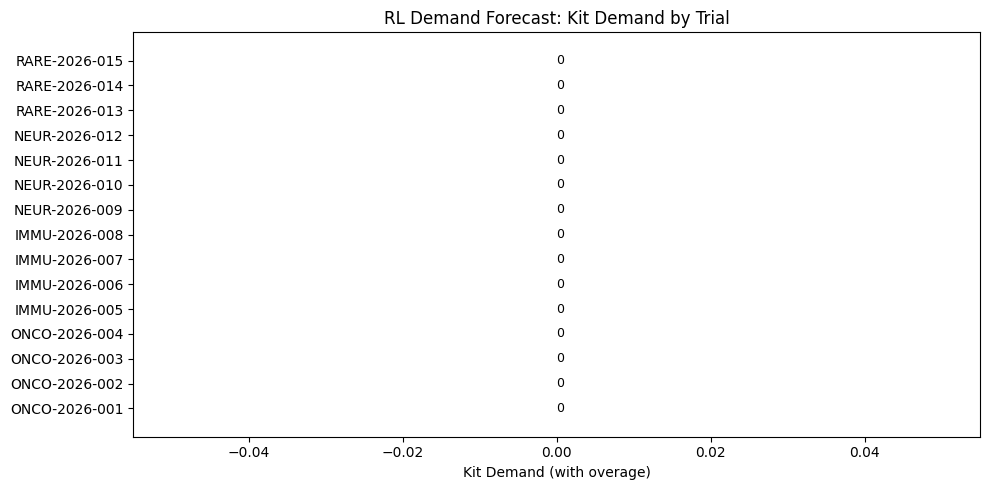

In [9]:
# Plot: Kit demand by trial
fig, ax = plt.subplots(figsize=(10, 5))
protocols = list(demand_plan.demand_by_trial.keys())
kits = list(demand_plan.demand_by_trial.values())
colors = plt.cm.Set2(np.linspace(0, 1, len(protocols)))
ax.barh(protocols, kits, color=colors)
ax.set_xlabel("Kit Demand (with overage)")
ax.set_title("RL Demand Forecast: Kit Demand by Trial")
for i, v in enumerate(kits):
    ax.text(v + max(kits) * 0.01, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

---

## 4. Deep Dive: Capacity Allocation Agent

The capacity agent distributes plant and depot capacity across trials.

**Observation** (140-dim): 10 locations x 4 features + 20 trials x 5 features
- Locations: `total_capacity`, `utilization`, `num_lines`, `pending_campaigns`
- Trials: `priority`, `demand`, `demand_3m`, `inventory`, `days_of_supply`

**Action** (200-dim): 10 x 20 allocation matrix (softmax-normalized per location)

**Outputs**: `DepotCapacityPlan`, `PlantCapacityPlan`, `PortfolioPlan`

In [10]:
# Build observation
obs_cap, loc_map, trl_map = build_capacity_obs(demo_state)
print(f"Capacity observation shape: {obs_cap.shape}")
print(f"Locations mapped: {len(loc_map)},  Trials mapped: {len(trl_map)}")

# Show location features
loc_feature_names = ["total_capacity", "utilization", "num_lines", "pending_campaigns"]
loc_rows = []
for i in range(len(loc_map)):
    vals = obs_cap[i * LOC_FEATURES : (i + 1) * LOC_FEATURES]
    loc_rows.append(dict(zip(loc_feature_names, vals)))
pd.DataFrame(loc_rows, index=[f"loc_{i}" for i in range(len(loc_rows))])

Capacity observation shape: (140,)
Locations mapped: 8,  Trials mapped: 15


,total_capacity,utilization,num_lines,pending_campaigns
loc_0,416.666656,0.0,4.0,0.0
loc_1,333.333344,0.0,3.0,0.0
loc_2,500.000000,0.0,5.0,0.0
loc_3,600.000000,0.0,7.0,0.0
loc_4,400.000000,0.0,4.0,0.0
loc_5,200.000000,0.0,2.0,0.0
loc_6,250.000000,0.0,4.0,0.0
loc_7,150.000000,0.0,2.0,0.0


In [11]:
# Load model, predict, and map
cap_model = PPO.load(str(MODEL_DIR / "capacity_allocation.zip"))
action_cap, _ = cap_model.predict(obs_cap, deterministic=True)

depot_plan, plant_plan, portfolio_plan = map_capacity_action(action_cap, demo_state, loc_map, trl_map)

# Store on state for downstream agents
demo_state.set("demand_plan", demand_plan)
demo_state.set("depot_capacity_plan", depot_plan)
demo_state.set("plant_capacity_plan", plant_plan)
demo_state.set("portfolio_plan", portfolio_plan)

print("=== Plant Capacity ===")
for cal in plant_plan.plant_calendars:
    print(f"  {cal.location_name}: {cal.utilization_pct:.1f}% utilized, {cal.available_slots} slots available")

print("\n=== Depot Capacity ===")
for cal in depot_plan.depot_calendars:
    print(f"  {cal.location_name}: {cal.utilization_pct:.1f}% utilized, {cal.available_slots} slots available")

print(f"\nFeasible: {depot_plan.feasible}")

=== Plant Capacity ===
  Springfield Pilot Plant: 100.0% utilized, 0 slots available
  Basel Pilot Plant: 100.0% utilized, 0 slots available

=== Depot Capacity ===
  US Regional Depot: 100.0% utilized, 0 slots available
  EU Regional Depot: 100.0% utilized, 0 slots available
  APAC Regional Depot: 100.0% utilized, 0 slots available
  US East Local Depot: 100.0% utilized, 0 slots available
  EU Central Local Depot: 100.0% utilized, 0 slots available
  APAC East Local Depot: 100.0% utilized, 0 slots available

Feasible: False


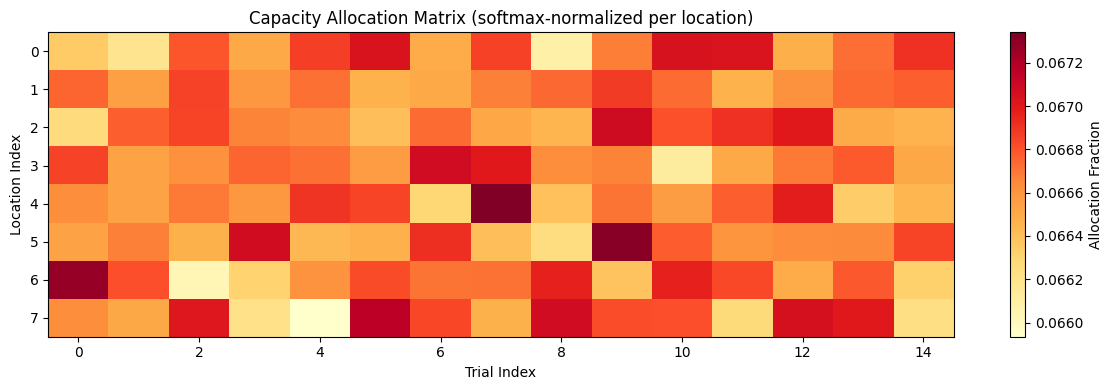


=== Portfolio Ranking ===
  # 1  ONCO-2026-003         phase_iii   priority=3  alloc=0.067
  # 2  IMMU-2026-007         phase_iii   priority=3  alloc=0.067
  # 3  IMMU-2026-008         phase_iii   priority=3  alloc=0.067
  # 4  NEUR-2026-011         phase_iii   priority=3  alloc=0.067
  # 5  RARE-2026-015         phase_iii   priority=3  alloc=0.067
  # 6  ONCO-2026-002         phase_ii    priority=2  alloc=0.067
  # 7  ONCO-2026-004         phase_ii    priority=2  alloc=0.067
  # 8  IMMU-2026-006         phase_ii    priority=2  alloc=0.067
  # 9  NEUR-2026-010         phase_ii    priority=2  alloc=0.067
  #10  NEUR-2026-012         phase_ii    priority=2  alloc=0.067


In [12]:
# Plot: Allocation matrix heatmap (softmax-normalized per location)
n_locs = len(loc_map)
n_trials = len(trl_map)
raw = action_cap[:n_locs * n_trials].reshape(n_locs, n_trials)
alloc = np.zeros_like(raw)
for i in range(n_locs):
    exp_row = np.exp(raw[i] - np.max(raw[i]))
    alloc[i] = exp_row / (exp_row.sum() + 1e-8)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(alloc, aspect="auto", cmap="YlOrRd")
ax.set_xlabel("Trial Index")
ax.set_ylabel("Location Index")
ax.set_title("Capacity Allocation Matrix (softmax-normalized per location)")
plt.colorbar(im, ax=ax, label="Allocation Fraction")
plt.tight_layout()
plt.show()

# Portfolio ranking
print("\n=== Portfolio Ranking ===")
for t in portfolio_plan.ranked_trials[:10]:
    print(f"  #{t['rank']:2d}  {t['protocol']:20s}  {t['phase']:10s}  priority={t['priority_score']}  alloc={t['capacity_allocation']:.3f}")

---

## 5. Deep Dive: Batch Scheduling Agent

The batch agent schedules production runs on equipment lines.

**Observation** (442-dim):
- 40 equipment lines x 5 features: `capacity_per_day`, `available_days`, `current_material`, `changeover`, `utilization`
- 80 materials x 3 features: `pending_demand`, `inventory`, `nominal_batch`
- 2 global features: `month_index`, `total_demand`

**Action** (120-dim): 40 lines x 3 values: `material_idx`, `num_batches` [0-5], `batch_size_multiplier` [0.5-1.5]

**Output**: `SupplyPlan` with `Batch` objects

In [13]:
# Build observation
obs_batch, line_map, mat_map = build_batch_obs(demo_state)
print(f"Batch observation shape: {obs_batch.shape}")
print(f"Equipment lines mapped: {len(line_map)},  Materials mapped: {len(mat_map)}")

# Load model, predict, and map
batch_model = PPO.load(str(MODEL_DIR / "batch_scheduling.zip"))
action_batch, _ = batch_model.predict(obs_batch, deterministic=True)
batch_supply_plan = map_batch_action(action_batch, demo_state, line_map, mat_map)

# Store on state for inventory agent
demo_state.set("supply_plan", batch_supply_plan)

print(f"\nBatches scheduled: {len(batch_supply_plan.batches)}")
print(f"Horizon: {batch_supply_plan.horizon_start} to {batch_supply_plan.horizon_end}")

# Display batch details
if batch_supply_plan.batches:
    batch_df = pd.DataFrame([
        {
            "batch_number": b.batch_number,
            "stage": b.stage.value,
            "quantity": f"{b.quantity:,.0f}",
            "status": b.status.value,
            "planned_start": str(b.planned_start),
            "planned_end": str(b.planned_end),
        }
        for b in batch_supply_plan.batches[:15]
    ])
    display(batch_df)
else:
    print("  (no batches scheduled)")

Batch observation shape: (442,)
Equipment lines mapped: 31,  Materials mapped: 60

Batches scheduled: 0
Horizon: 2026-03-15 to 2027-03-15
  (no batches scheduled)


In [14]:
# Plot: Batches per supply chain stage
if batch_supply_plan.batches:
    stage_counts = {}
    stage_qty = {}
    for b in batch_supply_plan.batches:
        stage_counts[b.stage.value] = stage_counts.get(b.stage.value, 0) + 1
        stage_qty[b.stage.value] = stage_qty.get(b.stage.value, 0) + b.quantity

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.bar(stage_counts.keys(), stage_counts.values(), color="steelblue")
    ax1.set_ylabel("Number of Batches")
    ax1.set_title("Batch Count by Stage")

    ax2.bar(stage_qty.keys(), stage_qty.values(), color="coral")
    ax2.set_ylabel("Total Quantity")
    ax2.set_title("Production Volume by Stage")

    plt.tight_layout()
    plt.show()

---

## 6. Deep Dive: Inventory & Safety Stock Agent

The inventory agent sets reorder quantities and safety stock targets.

**Observation** (800-dim): 100 inventory positions x 8 features:
- `on_hand`, `in_transit`, `on_order`, `allocated`, `available`
- `days_of_supply`, `monthly_demand_estimate`, `lead_time`

**Action** (200-dim): 100 positions x 2 values: `reorder_qty` [0-500], `safety_target_months` [0.5-6.0]

**Output**: `SupplyPlan` with `SupplyOrder` and `InventoryPosition` projections

In [15]:
# Build observation
obs_inv, inv_map = build_inventory_obs(demo_state)
print(f"Inventory observation shape: {obs_inv.shape}")
print(f"Positions mapped: {len(inv_map)}")

# Show first few positions
inv_feature_names = [
    "on_hand", "in_transit", "on_order", "allocated",
    "available", "days_of_supply", "demand_est", "lead_time",
]
inv_rows = []
for i in range(min(5, len(inv_map))):
    vals = obs_inv[i * INV_FEATURES : (i + 1) * INV_FEATURES]
    inv_rows.append(dict(zip(inv_feature_names, vals)))
pd.DataFrame(inv_rows, index=[f"pos_{i}" for i in range(len(inv_rows))])

Inventory observation shape: (800,)
Positions mapped: 60


,on_hand,in_transit,on_order,allocated,available,days_of_supply,demand_est,lead_time
pos_0,15.800000,0.0,0.0,0.0,20.500000,43.849308,0.0,66.0
pos_1,10.500000,0.0,0.0,0.0,1.800000,74.267899,0.0,66.0
pos_2,18.700001,0.0,0.0,0.0,9.600000,31.604933,0.0,66.0
pos_3,18.400000,0.0,0.0,0.0,24.600000,49.617352,0.0,66.0
pos_4,29.700001,0.0,0.0,0.0,32.599998,75.610283,0.0,66.0


In [16]:
# Load model, predict, and map
inv_model = PPO.load(str(MODEL_DIR / "inventory_safety_stock.zip"))
action_inv, _ = inv_model.predict(obs_inv, deterministic=True)
inv_supply_plan = map_inventory_action(action_inv, demo_state, inv_map)

print(f"Reorder orders created:     {len(inv_supply_plan.orders)}")
print(f"Inventory projections:      {len(inv_supply_plan.inventory_projections)}")
print(f"Shortfall alerts:           {len(inv_supply_plan.shortfall_alerts)}")

# Show top reorders
if inv_supply_plan.orders:
    order_df = pd.DataFrame([
        {
            "stage": o.stage.value,
            "quantity": f"{o.quantity:,.0f}",
            "status": o.status.value,
            "required_date": str(o.required_date),
        }
        for o in inv_supply_plan.orders[:10]
    ])
    display(order_df)

Reorder orders created:     0
Inventory projections:      60
Shortfall alerts:           0


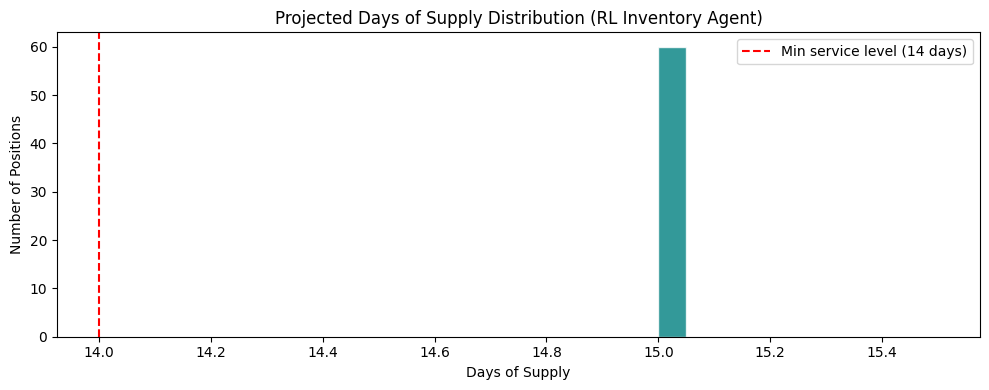

In [17]:
# Plot: Projected days of supply distribution
if inv_supply_plan.inventory_projections:
    dos_values = [p.days_of_supply for p in inv_supply_plan.inventory_projections if p.days_of_supply > 0]
    if dos_values:
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.hist(dos_values, bins=20, color="teal", edgecolor="white", alpha=0.8)
        ax.axvline(14, color="red", linestyle="--", label="Min service level (14 days)")
        ax.set_xlabel("Days of Supply")
        ax.set_ylabel("Number of Positions")
        ax.set_title("Projected Days of Supply Distribution (RL Inventory Agent)")
        ax.legend()
        plt.tight_layout()
        plt.show()

---

## 7. Reward Functions

Each RL agent is trained using a domain-specific reward function. These combine multiple
weighted components to balance competing objectives (e.g., minimizing stockouts vs. holding costs).

| Agent | Reward Components | Key Weights |
|-------|------------------|-------------|
| Demand Forecast | -MAE, -bias penalty | w_mae=1.0, w_bias=5.0 |
| Inventory | -stockout, -holding, -expiry, +service | w_stockout=10.0, w_expiry=5.0 |
| Batch Scheduling | -unmet demand, -changeover, -idle, +on-time | w_unmet=10.0, w_on_time=2.0 |
| Capacity Allocation | -infeasibility, -imbalance, +priority align | w_infeasible=100.0, w_priority=5.0 |

In [18]:
# Demonstrate each reward function with sample data

rng = np.random.default_rng(42)

# 1. Demand forecast reward
predicted = rng.uniform(5, 30, size=20)
actual = predicted + rng.normal(0, 3, size=20)  # slight noise
r_demand = demand_forecast_reward(predicted, actual)
print(f"Demand Forecast Reward:     {r_demand:.3f}")
print(f"  (MAE = {np.mean(np.abs(predicted - actual)):.2f}, bias = {np.abs(np.mean(predicted - actual)):.2f})")

# 2. Inventory reward
on_hand = rng.uniform(50, 500, size=10).astype(np.float32)
demand = rng.uniform(20, 200, size=10).astype(np.float32)
expired = rng.uniform(0, 10, size=10).astype(np.float32)
dos = rng.uniform(5, 60, size=10).astype(np.float32)
r_inv = inventory_reward(on_hand, demand, expired, dos)
print(f"\nInventory Reward:            {r_inv:.3f}")
print(f"  (stockouts = {np.sum(np.maximum(demand - on_hand, 0)):.0f}, service positions = {np.sum(dos > 14)})")

# 3. Batch scheduling reward
unmet = rng.uniform(0, 50, size=5).astype(np.float32)
changeover = rng.uniform(0, 3, size=5).astype(np.float32)
idle = rng.uniform(0, 10, size=5).astype(np.float32)
r_batch = batch_scheduling_reward(unmet, changeover, idle, on_time_batches=8)
print(f"\nBatch Scheduling Reward:     {r_batch:.3f}")
print(f"  (unmet demand = {np.sum(unmet):.0f}, on-time batches = 8)")

# 4. Capacity allocation reward
util = rng.uniform(0.3, 0.95, size=4).astype(np.float32)
dos_trial = rng.uniform(10, 50, size=6).astype(np.float32)
alloc_frac = rng.dirichlet(np.ones(6), size=4).flatten().astype(np.float32)
priorities = np.array([3, 2, 1, 3, 2, 1], dtype=np.float32)
r_cap = capacity_allocation_reward(util, dos_trial, alloc_frac, priorities)
print(f"\nCapacity Allocation Reward:  {r_cap:.3f}")
print(f"  (infeasible locations = {np.sum(util > 1.0)}, supply variance = {np.var(dos_trial):.1f})")

Demand Forecast Reward:     -3.564
  (MAE = 1.92, bias = 0.33)

Inventory Reward:            -269.815
  (stockouts = 0, service positions = 9)

Batch Scheduling Reward:     -1042.709
  (unmet demand = 104, on-time batches = 8)

Capacity Allocation Reward:  -186.674
  (infeasible locations = 0, supply variance = 94.6)


---

## 8. Training Demo

Each RL agent trains in its own Gymnasium environment that simulates supply chain dynamics
with stochastic noise (+/-15% CV). The `BaseRLAgent.train()` method wraps SB3 PPO with
sensible defaults:

| Hyperparameter | Value |
|---------------|-------|
| Algorithm | PPO (MlpPolicy) |
| Learning rate | 3e-4 |
| n_steps | 2,048 |
| batch_size | 64 |
| n_epochs | 10 |
| gamma | 0.99 |
| clip_range | 0.2 |
| ent_coef | 0.01 |
| Default timesteps | 500,000 |

Below we train the demand agent for a very small number of timesteps as a demonstration.
Full training is done via `python -m csc.cli train`.

In [19]:
# Inspect a training environment
from csc.rl.envs.demand_env import DemandForecastEnv

env = DemandForecastEnv(seed=42)
obs, info = env.reset()

print("=== Demand Forecast Training Environment ===")
print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Horizon:           {env._horizon} months")
print(f"Trial-site pairs:  {env._n_pairs}")
print(f"\nInitial observation shape: {obs.shape}")
print(f"Non-zero features:         {np.count_nonzero(obs)}")

# Take a random step to see the reward signal
random_action = env.action_space.sample()
obs_next, reward, terminated, truncated, info = env.step(random_action)
print(f"\nRandom action reward:      {reward:.3f}")
print(f"Terminated:                {terminated}")

=== Demand Forecast Training Environment ===
Observation space: Box(0.0, 1e+06, (1500,), float32)
Action space:      Box(0.0, 200.0, (300,), float32)
Horizon:           24 months
Trial-site pairs:  113

Initial observation shape: (1500,)
Non-zero features:         770

Random action reward:      -644.908
Terminated:                False


In [20]:
# Train the demand agent for a tiny number of steps (demo only)
# Full training: python -m csc.cli train --agent demand_forecast --timesteps 500000

import tempfile

train_state = SharedState()
agent = DemandRLAgent(state=train_state)

with tempfile.TemporaryDirectory() as tmpdir:
    save_path = Path(tmpdir) / "demand_forecast_demo.zip"
    agent.train(total_timesteps=2_048, seed=42, save_path=save_path)
    print(f"\nDemo model saved to: {save_path}")
    print(f"File size: {save_path.stat().st_size / 1024:.1f} KB")

Training demand_forecast for 2,048 timesteps...

Using cpu device
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 24       |
|    ep_rew_mean     | -185     |
| time/              |          |
|    fps             | 48       |
|    iterations      | 1        |
|    time_elapsed    | 41       |
|    total_timesteps | 2048     |
---------------------------------


Model saved to C:\Users\Ferhat\AppData\Local\Temp\tmpx4s724_f\demand_forecast_demo.zip


Demo model saved to: C:\Users\Ferhat\AppData\Local\Temp\tmpx4s724_f\demand_forecast_demo.zip
File size: 2650.7 KB


---

## 9. Multi-Agent Environment (PettingZoo)

`SupplyChainMultiAgentEnv` wraps all 4 single-agent environments into a PettingZoo
AEC (Alternating Execution Context) environment for joint training.

**Agent execution order** (each round):
1. `demand_forecaster` — predicts enrollment
2. `capacity_allocator` — distributes capacity
3. `batch_scheduler` — schedules production
4. `inventory_manager` — manages stock

**Coordination mechanism**: After each agent acts, a summary of its action (mean, std, min, max)
is appended to a shared coordination vector. Subsequent agents see this vector concatenated
to their observation, enabling implicit coordination without explicit communication.

In [21]:
from csc.rl.envs.supply_chain_env import SupplyChainMultiAgentEnv, AGENT_ORDER

ma_env = SupplyChainMultiAgentEnv(seed=42, horizon_months=3)
ma_env.reset()

print("=== Multi-Agent Supply Chain Environment ===")
print(f"Agents: {ma_env.agents}")
print(f"Horizon: {ma_env._horizon} months")
print(f"Coordination vector dim: {len(AGENT_ORDER) * ma_env._coord_dim}")
print()

for agent_name in AGENT_ORDER:
    obs_space = ma_env.observation_space(agent_name)
    act_space = ma_env.action_space(agent_name)
    sub_obs_dim = ma_env._sub_envs[agent_name].observation_space.shape[0]
    coord_dim = len(AGENT_ORDER) * ma_env._coord_dim
    print(f"  {agent_name:25s}  obs: {obs_space.shape[0]:5d} ({sub_obs_dim} + {coord_dim} coord)  act: {act_space.shape[0]:4d}")

c:\Users\Ferhat\Documents\GitHub\csc-skill-test\rl\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\Ferhat\Documents\GitHub\csc-skill-test\rl\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


=== Multi-Agent Supply Chain Environment ===
Agents: ['demand_forecaster', 'capacity_allocator', 'batch_scheduler', 'inventory_manager']
Horizon: 3 months
Coordination vector dim: 64

  demand_forecaster          obs:  1564 (1500 + 64 coord)  act:  300
  capacity_allocator         obs:   204 (140 + 64 coord)  act:  200
  batch_scheduler            obs:   506 (442 + 64 coord)  act:  120
  inventory_manager          obs:   864 (800 + 64 coord)  act:  200


In [22]:
# Run one full round of the multi-agent environment with random actions
ma_env.reset()
round_results = []

for agent_name in AGENT_ORDER:
    obs = ma_env.observe(agent_name)
    action = ma_env.action_space(agent_name).sample()
    ma_env.step(action)
    round_results.append({
        "agent": agent_name,
        "obs_dim": obs.shape[0],
        "action_dim": action.shape[0],
        "reward": ma_env.rewards[agent_name],
        "terminated": ma_env.terminations[agent_name],
    })

pd.DataFrame(round_results)

,agent,obs_dim,action_dim,reward,terminated
0,demand_forecaster,1564,300,-6.093974e+02,False
1,capacity_allocator,204,200,-1.254945e+06,False
2,batch_scheduler,506,120,-3.022258e+04,False
3,inventory_manager,864,200,-1.930481e+05,False


---

## 10. CLI Reference

The RL pipeline can also be run entirely from the command line:

```bash
# Generate synthetic data
python -m csc.cli generate --trials 8 --sites 30 --seed 42

# Train all 4 RL agents (500K timesteps each by default)
python -m csc.cli train

# Train a single agent
python -m csc.cli train --agent demand_forecast --timesteps 100000

# Run the full RL pipeline and generate reports
python -m csc.cli run --all --method rl

# Run with custom data/model directories
python -m csc.cli run --all --method rl --data-dir path/to/data --output-dir path/to/reports
```

Configuration can also be set via environment variables or a `.env` file:

| Variable | Default | Description |
|----------|---------|-------------|
| `CSC_METHOD` | `llm` | Pipeline method: `llm` or `rl` |
| `CSC_RL_MODEL_DIR` | `src/csc/rl/models` | Directory for trained PPO models |
| `CSC_RL_TRAINING_TIMESTEPS` | `500000` | Training steps per agent |
| `CSC_RL_TRAINING_SEED` | `42` | Random seed for reproducibility |